### Libraries and Imports


In [39]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from datetime import date
%matplotlib inline
from trajectory_video import make_trajectory_video
from trajectory_video2 import make_trajectory_video1
from training_progress_video import make_training_progress_video
import re
import glob
import matplotlib as mpl
import matplotlib.animation as animation
import imageio_ffmpeg
mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

### PDE and FD reference Parameters and RL action space


In [40]:
# PDE  — Burgers:  u_t + u u_x = alpha u_xx
alpha = 0.1

#   FD reference grid
nx    = 100
T     = 0.5                      # match the Burgers reference in notebook 4 (was 1)
x_fd  = np.linspace(0.0, 1.0, nx)
dx    = x_fd[1] - x_fd[0]

# CFL now has TWO limits: advective (u u_x) and diffusive (alpha u_xx)
u_max  = 1.5                     # IC amplitude bound: max|sin(pi x)+0.5 sin(2pi x)|
dt_cfl = min(0.9 * dx / u_max,
             0.45 * dx**2 / alpha)
nt     = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt)
dt     = t_fd[1] - t_fd[0]

# ── True solution: analytical Burgers via Hopf-Cole (Fourier cosine series) ──
#    IC:  u0(x) = sin(pi x) + 0.5 sin(2 pi x)
_xq = np.linspace(0.0, 1.0, 20001)
_phi0 = np.exp(
    -(
        (1 - np.cos(np.pi * _xq)) / np.pi
        + 0.5 * (1 - np.cos(2 * np.pi * _xq)) / (2 * np.pi)
    )
    / (2 * alpha)
)

_N_SERIES = 200
_a = np.zeros(_N_SERIES + 1)
_a[0] = np.trapezoid(_phi0, _xq)
for n in range(1, _N_SERIES + 1):
    _a[n] = 2.0 * np.trapezoid(_phi0 * np.cos(n * np.pi * _xq), _xq)

_n_arr  = np.arange(1, _N_SERIES + 1)
_an     = _a[1:]
_lam_hc = -alpha * (_n_arr * np.pi) ** 2

def u_true(x, t):
    x = np.asarray(x, dtype=float)
    scalar = x.ndim == 0
    x = np.atleast_1d(x)

    cos_nx = np.cos(np.pi * np.outer(x, _n_arr))
    sin_nx = np.sin(np.pi * np.outer(x, _n_arr))
    exp_t  = np.exp(_lam_hc * t)

    phi   =  _a[0] + (cos_nx * (_an * exp_t)).sum(axis=-1)
    phi_x = -(sin_nx * (_an * _n_arr * np.pi * exp_t)).sum(axis=-1)

    result = -2 * alpha * phi_x / phi
    return float(result[0]) if scalar else result

### FD For diffusion

In [41]:
def build_fd_reference():
    u = np.zeros((nx, nt))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt / dx**2

    for it in range(nt - 1):
        un = u[:, it]
        r_adv_local = un * dt / dx                       # local advection speed = u
        u[1:-1, it+1] = (un[1:-1]
                         - r_adv_local[1:-1] * (un[1:-1] - un[:-2])   # upwind u u_x
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))  # diffusion
        u[0,   it+1] = 0.0
        u[-1,  it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
            bounds_error=False, fill_value=None
    )
    return u, interp

### __ init __

In [42]:
class VisitedSet:
    def __init__(self, cap0=8192):
        self._cap  = cap0
        self._n    = 0
        self._store     = np.empty((cap0, 3), dtype=float)   # (x, t, u)
        self._normstore = np.empty((cap0, 2), dtype=float)   # (x/dx, t/dt)
        self._idx_set   = set()
        self.rejected_history = []

    def _grow(self):
        self._cap *= 2
        s  = np.empty((self._cap, 3)); s[:self._n]  = self._store[:self._n];     self._store = s
        ns = np.empty((self._cap, 2)); ns[:self._n] = self._normstore[:self._n]; self._normstore = ns

    def add(self, x, t, u):
        if self._n == self._cap:
            self._grow()
        self._store[self._n]     = (x, t, u)
        self._normstore[self._n] = (x / dx, t / dt)
        self._idx_set.add((round(x / dx), round(t / dt)))
        self._n += 1

    # live-slice views so plot/video code that iterates ._pts keeps working
    @property
    def _pts(self):
        return self._store[:self._n]

    @property
    def _norm(self):
        return self._normstore[:self._n]

    def contains(self, x, t):
        return (round(x / dx), round(t / dt)) in self._idx_set

    def find_neighbours(self, x_star, t_star, n, causal=True, box_R=None):
        if self._n < n:
            return None
        pts_arr  = self._store[:self._n]
        norm_arr = self._normstore[:self._n]

        if causal:
            mask = pts_arr[:, 1] <= t_star
        else:
            mask = np.ones(self._n, dtype=bool)

        same_cell = (np.round(pts_arr[:, 0] / dx) == round(x_star / dx)) & \
                    (np.round(pts_arr[:, 1] / dt) == round(t_star / dt))
        mask &= ~same_cell

        if box_R is not None:
            in_box = (np.abs(pts_arr[:, 0] - x_star) <= box_R * dx + 1e-9) & \
                     (np.abs(pts_arr[:, 1] - t_star) <= box_R * dt + 1e-9)
            mask &= in_box

        if mask.sum() < n:
            return None
        norm_c = norm_arr[mask]
        pts_c  = pts_arr[mask]
        target = np.array([x_star / dx, t_star / dt])
        d2     = np.sum((norm_c - target) ** 2, axis=1)
        idx = np.argpartition(d2, n - 1)[:n]
        idx = idx[np.argsort(d2[idx])]
        return [tuple(row) for row in pts_c[idx]]

    def count_in_box(self, x_star, t_star, R):
        ci = round(x_star / dx)
        cj = round(t_star / dt)
        cnt = 0
        for di in range(-R, R + 1):
            for dj in range(-R, R + 1):
                if di == 0 and dj == 0:
                    continue
                if (ci + di, cj + dj) in self._idx_set:
                    cnt += 1
        return cnt

    def __len__(self):
        return self._n

### GFDM Solver


In [43]:
def solve_weights(dx_i, dt_i, u_nb=None, strict=True):
    h = max(np.max(np.abs(dx_i)), np.sqrt(alpha * np.max(np.abs(dt_i))), 1e-12)

    c_local = float(np.mean(u_nb))
    
    A = np.array([
        np.ones(len(dx_i)),
        (dx_i - c_local * dt_i) / h,               # u_x row: now carries -c u_x from u_t
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,      # u_xx row (unchanged)
    ])
    b = np.array([1.0, 0.0, 0.0])

    cond = np.linalg.cond(A)
    if strict and cond > 1e4:
        return None, 'cond'

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    if strict and np.abs(w).sum() > 2.0:
        return None, 'weights'

    return w, 'ok'

### PDEEnvironment

In [ ]:
from logging import info

from matplotlib.pyplot import box


class PDEEnvironment(gym.Env):
    ACTIONS = {0:  (-1, 2),
                1:  ( 0, 2),
                2:  ( 1, 2),

                3:  (-2, 5),
                4:  (-1, 5),
                5:  ( 0, 5),
                6:  ( 1, 5),
                7:  ( 2, 5),

                8:  (-3, 8),
                9:  (-2, 8),
                10: (-1, 8),
                11: ( 0, 8),
                12: ( 1, 8),
                13: ( 2, 8),
                14: ( 3, 8),

                15: (-4, 15),
                16: (-3, 15),
                17: (-2, 15),
                18: (-1, 15),
                19: ( 0, 15),
                20: ( 1, 15),
                21: ( 2, 15),
                22: ( 3, 15),
                23: ( 4, 15)
                }
    
    def __init__(self, R_bubble,t_star_schedule=None, t_star_steps=2, N_particles=27,err_tol=1e-3, w_err=0.8, w_time=0.2,
             K_max=5000, c_shape=0.05, x_star_schedule=None,
             causal_moves=False):
        super().__init__()

        self.alpha = alpha
        self.c_shape = c_shape
        self.ERR_CEIL = 2.2
        self.n_neighbours = 5
        self.R_bubble = R_bubble
        self.nx = nx; self.nt = nt
        self.x_fd = x_fd; self.t_fd = t_fd
        self.dx = dx; self.dt = dt; self.T = T

        self.t_star_schedule = dict(t_star_schedule) if t_star_schedule else None

        # ── x* schedule: list of grid indices to sample from. None → fixed center.
        # Store as x_fd values so x* always lands on the grid.
        if x_star_schedule is not None:
            self.x_star_choices = np.array(
                [self.x_fd[int(ix)] for ix in x_star_schedule], dtype=float)
        else:
            self.x_star_choices = None

        # ── Target point (z*) ──
        self.x_star = self.x_fd[self.nx // 2]     # provisional; reset() may override
        self.t_star_steps = t_star_steps
        self.t_star = t_star_steps * dt

        self.K_max = K_max
        self.err_tol = err_tol
        self.w_err = w_err
        self.w_time = w_time
        self.phi_scale = 1.0
        self.n_neighbours = 5
        self.eps_x = 0.5 * dx
        self.eps_t = 0.5 * dt
        self.retry_after = 50
        # Neighbour search for WALKER MOVES: False -> stencils may draw on points
        # both below and above t_new (the star solve was already non-causal).
        self.causal_moves = causal_moves
        # ── Walker initial positions: FROZEN to domain center, INDEPENDENT of x* ──
        self.N = N_particles
        mid = self.nx // 2
        margin = 2
        half_n = self.N // 2
        step = (mid - margin) / half_n if half_n > 0 else 0
        offsets = [0]; k = 1
        while len(offsets) < self.N:
            offsets.append(k * step)
            if len(offsets) < self.N:
                offsets.append(-k * step)
            k += 1
        init_idx = np.clip(
            np.round(np.array(offsets[:self.N]) + mid).astype(int),
            margin, self.nx - 1 - margin)
        self.walker_init_x = self.x_fd[init_idx]   # does NOT depend on x_star

        _, self.fd_interp = build_fd_reference()

        self.visited = None
        self.walker_x = None
        self._bubble_dirty = True
        self._bubble_solve = (None, False)
        self.walker_t = None
        self.walker_u = None
        self.step_count = 0
        self.stencil_log = {}

        # obs: 2N relative coords + t*_norm + x*_norm  → 2N+2
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(2 * self.N + 2,), dtype=np.float32)
        self.action_space = spaces.Discrete(self.N * len(self.ACTIONS))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        if self.t_star_schedule is not None:
            choices = list(self.t_star_schedule.keys())
            self.t_star_steps = int(self.np_random.choice(choices))
            self.t_star = self.t_star_steps * self.dt
            self.K_max = self.t_star_schedule[self.t_star_steps]

        # ── Resample x* per episode if a schedule is set ──
        if self.x_star_choices is not None:
            self.x_star = float(self.np_random.choice(self.x_star_choices))

        self.visited = VisitedSet()
        self.stencil_log = {}

        for ix in range(self.nx):
            x = self.x_fd[ix]
            self.visited.add(x, 0.0, u_true(x, 0.0))
        for it in range(1, self.nt):
            self.visited.add(0.0, self.t_fd[it], 0.0)
            self.visited.add(1.0, self.t_fd[it], 0.0)

        self.walker_x = np.array(self.walker_init_x, dtype=float)
        self.walker_t = np.zeros(self.N)
        self.walker_u = np.array([u_true(x, 0.0) for x in self.walker_x])
        self.step_count = 0
        self.rejected_history = []
        self.gfdm_rejected_cells = {} 
        self.phi_scale = max(self._mean_target_distance(), 1e-12)
        self._phi_prev = self._potential()
        self._bubble_dirty = True
        self._bubble_solve = (None, False)

        return self._build_obs(), {}

    def _build_obs(self):
        dx_rel = (self.walker_x - self.x_star) / self.dx
        dt_rel = (self.walker_t - self.t_star) / self.dt
        t_star_norm = self.t_star / self.dt          # horizon length in step units
        x_star_norm = self.x_star / self.dx          # NEW: absolute x* in dx units
        return np.array([
            *dx_rel,
            *dt_rel,
            t_star_norm,
            x_star_norm,
        ], dtype=np.float32)

    def _mean_target_distance(self):
        dx_rel = (self.walker_x - self.x_star) / self.dx
        dt_rel = (self.walker_t - self.t_star) / self.dt
        d = np.sqrt(dx_rel**2 + dt_rel**2)
        return float(np.mean(d))

    def _potential(self):
        if self.c_shape == 0.0:
            return 0.0
        return -self.c_shape * self._mean_target_distance() / max(self.phi_scale, 1e-12)

    def _gfdm_solve(self, x_star, t_star, causal=True, box_R=None, strict=True):
        nb = self.visited.find_neighbours(x_star, t_star, self.n_neighbours, causal=causal, box_R=box_R)
        if nb is None:
            return None, False, None, 'no_nb'
        nb = np.array(nb)
        dx_i = nb[:, 0] - x_star
        dt_i = nb[:, 1] - t_star

        #if np.min(dx_i) * np.max(dx_i) > 0:          # all neighbours on one x-side → bad stencil
        #    return None, False, None, 'geometry'

        w, reason = solve_weights(dx_i, dt_i, nb[:, 2], strict=strict)      
        if w is None:
            return None, False, None, reason
        u_hat = float(w @ nb[:, 2])
        if strict and abs(u_hat) > 1.5:                                 
            return None, False, None, 'bounds_u'
        
        return u_hat, True, nb[:, :2], 'ok'

    def step(self, action):
        self.step_count += 1
        done = False
        reward = 0.0

        i = int(action) // len(self.ACTIONS)
        j = int(action) % len(self.ACTIONS)
        dx_idx, dt_idx = self.ACTIONS[j]
        dx_move = dx_idx * self.dx
        dt_move = dt_idx * self.dt

        info = {'walker': i, 'accepted': False, 'rejected': None, 'reached': False}

        x_new = self.walker_x[i] + dx_move
        t_new = self.walker_t[i] + dt_move

        # walkers may now rise to t* + R·dt (bubble extends above the star)
        t_ceil = self.t_star + self.R_bubble * self.dt + self.eps_t

        if not (0.0 <= x_new <= 1.0 and 0.0 < t_new <= t_ceil):
            info['rejected'] = 'bounds'
        elif self.visited.contains(x_new, t_new):
            info['rejected'] = 'collision'
        else:
            u_hat, success, nb_coords, reason = self._gfdm_solve(
                x_new, t_new, causal=self.causal_moves, strict=True)
            if not success:
                info['rejected'] = reason
                self.gfdm_rejected_cells[(round(x_new / self.dx), round(t_new / self.dt))] = len(self.visited)
            else:
                self.visited.add(x_new, t_new, u_hat)
                self.walker_x[i] = x_new
                self.walker_t[i] = t_new
                self.walker_u[i] = u_hat
                self.stencil_log[(round(x_new, 8), round(t_new, 8))] = nb_coords
                info['accepted'] = True
                # only a point landing inside the box can change the star solve
                if (abs(x_new - self.x_star) <= self.R_bubble * self.dx + 1e-9 and
                    abs(t_new - self.t_star) <= self.R_bubble * self.dt + 1e-9):
                    self._bubble_dirty = True

        if not info['accepted']:
            self.rejected_history.append((x_new, t_new, info['rejected']))

                # ── Unified termination: SOLVABLE bubble OR k_max reached ────────────
        # The stopping rule must ask the same question as the scoring rule:
        # "is there an admissible stencil at z*", not "are 5 points near z*".
        # Cheap counter gates the real solve; cached until the box changes.
        if self._bubble_dirty:
            self._bubble_dirty = False
            if self.visited.count_in_box(
                    self.x_star, self.t_star, self.R_bubble) >= self.n_neighbours:
                u_box, ok_box, _, _ = self._gfdm_solve(
                    self.x_star, self.t_star, causal=False, box_R=self.R_bubble, strict=True)
                self._bubble_solve = (u_box, ok_box)
            else:
                self._bubble_solve = (None, False)

        bubble_full = self._bubble_solve[1]
        timeout     = self.step_count >= self.K_max

        if bubble_full or timeout:
            done = True
            info['reached'] = bool(bubble_full)
            info['timeout'] = bool(timeout and not bubble_full)

            u_pred, _, _, _ = self._gfdm_solve(
                self.x_star, self.t_star, causal=False, box_R=None, strict=False)
            
            u_ref = u_true(self.x_star, self.t_star)

            if u_pred is None:
                err      = None
                err_norm = 1.0
            else:
                err      = min(abs(u_pred - u_ref), 1e3 * self.err_tol)
                err_norm = float(min(np.log10(max(err, 1e-12) / self.err_tol) / 3.0, 1.0))

            time_norm = self.step_count / max(self.K_max, 1)
            r_acc = -self.w_err  * err_norm
            r_eff = -self.w_time * time_norm
            reward = r_acc + r_eff              # accuracy + speed only

            info['u_pred']    = u_pred
            info['u_ref']     = u_ref
            info['error']     = err
            info['k_term']    = self.step_count
            info['err_norm']  = err_norm
            info['time_norm'] = time_norm
            info['r_acc']     = r_acc
            info['r_eff']     = r_eff

        phi_new = 0.0 if done else self._potential()
        shaping = phi_new - self._phi_prev
        self._phi_prev = phi_new
        reward += shaping
        info['shaping'] = shaping
        info['phi'] = phi_new

        return self._build_obs(), reward, done, False, info

    def action_masks(self) -> np.ndarray:
        n_act = len(self.ACTIONS)

        # per-action grid offsets, built from ACTIONS so this survives you
        # adding new moves later (e.g. the same-t (±1,0) action)
        adx = np.fromiter((self.ACTIONS[j][0] for j in range(n_act)), dtype=int, count=n_act)
        adt = np.fromiter((self.ACTIONS[j][1] for j in range(n_act)), dtype=int, count=n_act)

        # all N*n_act candidate positions at once
        x_new = self.walker_x[:, None] + adx[None, :] * self.dx      # (N, n_act)
        t_new = self.walker_t[:, None] + adt[None, :] * self.dt
        t_ceil = self.t_star + self.R_bubble * self.dt + self.eps_t

        ok = ((x_new >= 0.0) & (x_new <= 1.0) &
              (t_new > 0.0) & (t_new <= t_ceil)).ravel()

        # integer cells: ONE vectorized round instead of ~600 scalar round()/step
        cx = np.round(x_new / self.dx).astype(np.int64).ravel()
        ct = np.round(t_new / self.dt).astype(np.int64).ravel()

        n_pts   = len(self.visited)
        idx_set = self.visited._idx_set
        rej     = self.gfdm_rejected_cells
        retry   = self.retry_after

        for k in range(self.N * n_act):
            if not ok[k]:
                continue
            key = (int(cx[k]), int(ct[k]))
            if key in idx_set:                       # collision (was visited.contains)
                ok[k] = False
                continue
            n_fail = rej.get(key)                    # retry-window block
            if n_fail is not None and n_pts < n_fail + retry:
                ok[k] = False

        if not ok.any():
            ok[:] = True
        return ok

In [45]:
import inspect; print(inspect.signature(solve_weights))

(dx_i, dt_i, u_nb=None, strict=True)


### Sanity Check: Random Policy Baseline

Outcome:        bubble filled
Steps (k_term): 268
Points in box:  5  (need 5)
u_pred:         1.0234190755483101
u_ref:          1.0273737371734768
|error|:        3.955e-03
Final reward:   -0.1636   (r_acc=-0.15922915457379164, r_eff=-0.026800000000000004)
Total accepted: 162   |   Total rejected: 106
  weights   : 76
  cond      : 30


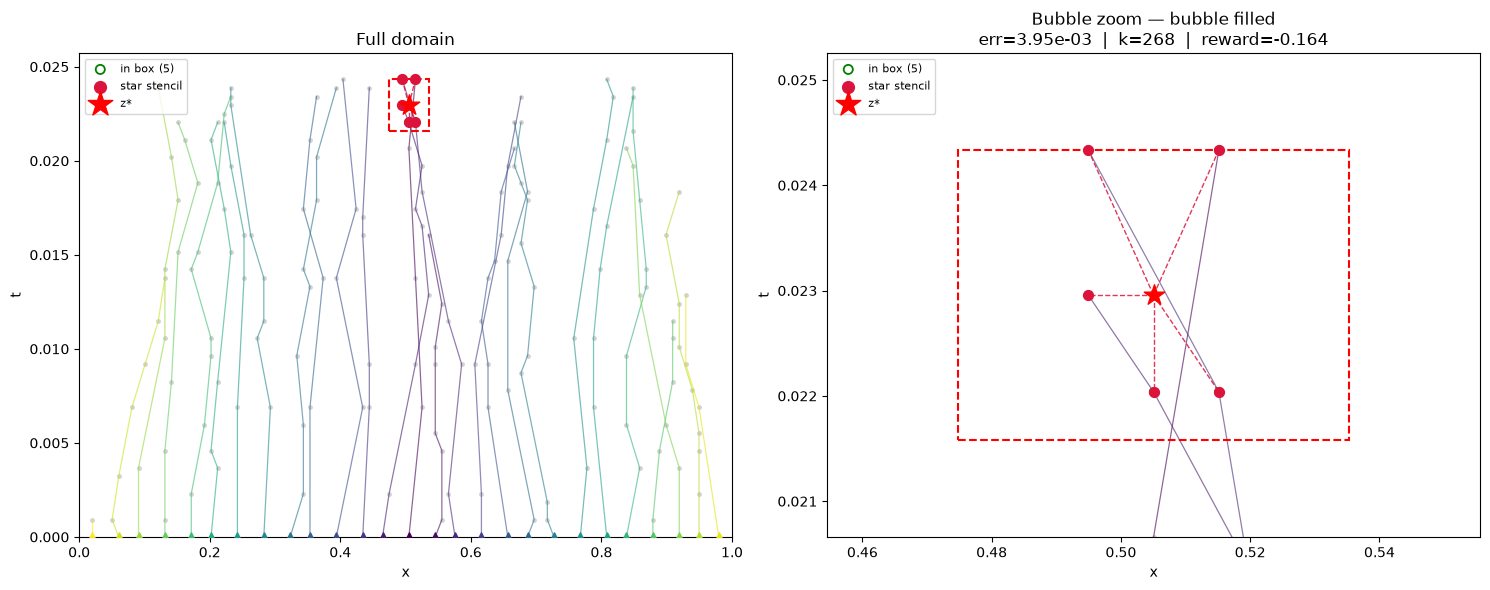

In [46]:
import matplotlib.patches as patches

R_bubble     = 3
t_star_steps = 50      # ← change to test different targets
K_max        = 2000

env    = PDEEnvironment(t_star_steps=t_star_steps, K_max=K_max, R_bubble=R_bubble)
obs, _ = env.reset()

trajectories   = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
done           = False
total_accepted = 0
total_rejected = {}

while not done:
    mask   = env.action_masks()
    action = int(np.random.choice(np.flatnonzero(mask)))   # masked random policy
    obs, reward, done, _, info = env.step(action)

    total_accepted += int(info['accepted'])
    if info['rejected']:
        total_rejected[info['rejected']] = total_rejected.get(info['rejected'], 0) + 1
    if info['accepted']:
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

# ── Outcome ───────────────────────────────────────────────────────────────────
reached = info.get('reached', False)
outcome = 'bubble filled' if reached else 'timeout (k_max)'
err     = info.get('error')
u_pred  = info.get('u_pred')
u_ref   = info.get('u_ref')
n_box   = env.visited.count_in_box(env.x_star, env.t_star, env.R_bubble)

print(f"Outcome:        {outcome}")
print(f"Steps (k_term): {info.get('k_term', env.step_count)}")
print(f"Points in box:  {n_box}  (need {env.n_neighbours})")
print(f"u_pred:         {u_pred}")
print(f"u_ref:          {u_ref}")
print(f"|error|:        {'None' if err is None else f'{err:.3e}'}")
print(f"Final reward:   {reward:.4f}   (r_acc={info.get('r_acc')}, r_eff={info.get('r_eff')})")
print(f"Total accepted: {total_accepted}   |   Total rejected: {sum(total_rejected.values())}")
for reason, count in sorted(total_rejected.items(), key=lambda kv: -kv[1]):
    print(f"  {reason:10s}: {count}")

# ── Plot ──────────────────────────────────────────────────────────────────────
visited_log = [(x, t) for (x, t, _) in env.visited._pts if t > 0.0 and 0.0 < x < 1.0]
Rx = env.R_bubble * env.dx
Rt = env.R_bubble * env.dt

# points inside the box (for highlighting)
in_box = [(x, t) for (x, t) in visited_log
          if abs(x - env.x_star) <= Rx + 1e-9 and abs(t - env.t_star) <= Rt + 1e-9]

# stencil the star solve actually used (non-causal)
_, s_ok, nb_coords, _ = env._gfdm_solve(
    env.x_star, env.t_star, causal=False,
    box_R=env.R_bubble if reached else None, strict=reached)

colors = plt.cm.viridis(np.linspace(0, 1, env.N))

def draw(ax):
    ax.scatter([p[0] for p in visited_log], [p[1] for p in visited_log],
               s=6, color='lightgray', zorder=1)
    # bubble box
    ax.add_patch(patches.Rectangle(
        (env.x_star - Rx, env.t_star - Rt), 2 * Rx, 2 * Rt,
        fill=False, edgecolor='red', linestyle='--', linewidth=1.5, zorder=4))
    # in-box points
    if in_box:
        ax.scatter([p[0] for p in in_box], [p[1] for p in in_box],
                   s=30, facecolors='none', edgecolors='green',
                   linewidths=1.3, zorder=5, label=f'in box ({len(in_box)})')
    # trajectories
    for i, traj in trajectories.items():
        xs = [p[0] for p in traj]; ts = [p[1] for p in traj]
        ax.plot(xs, ts, '-', linewidth=0.9, color=colors[i], alpha=0.6, zorder=2)
        ax.scatter(xs[0], ts[0], s=45, color=colors[i], marker='^', zorder=3)
    # star stencil
    if s_ok and nb_coords is not None:
        for (nxp, ntp) in nb_coords:
            ax.plot([env.x_star, nxp], [env.t_star, ntp], '--',
                    color='crimson', linewidth=1.0, alpha=0.85, zorder=6)
        ax.scatter(nb_coords[:, 0], nb_coords[:, 1], s=50, color='crimson',
                   zorder=7, label='star stencil')
    # star
    ax.scatter(env.x_star, env.t_star, s=240, color='red', marker='*',
               zorder=8, label='z*')
    ax.set_xlabel('x'); ax.set_ylabel('t')

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6))

# left: full domain
draw(axL)
axL.set_xlim(0, 1)
axL.set_ylim(0, env.t_star + (env.R_bubble + 3) * env.dt)
axL.set_title('Full domain')
axL.legend(fontsize=8, loc='upper left', markerscale=1.2)

# right: zoom on the bubble
draw(axR)
pad = (env.R_bubble + 2)
axR.set_xlim(env.x_star - pad * env.dx, env.x_star + pad * env.dx)
axR.set_ylim(env.t_star - pad * env.dt, env.t_star + pad * env.dt)
err_str = 'None' if err is None else f'{err:.2e}'
axR.set_title(f'Bubble zoom — {outcome}\nerr={err_str}  |  k={info.get("k_term", env.step_count)}  |  reward={reward:.3f}')
axR.legend(fontsize=8, loc='upper left', markerscale=1.2)

plt.tight_layout()
plt.show()

## Plot Trajactories


In [47]:
def plot_trajectories(model, t_star_steps, N_particles, err_tol, w_err, w_time, K_max, c_shape,
                      R_bubble, save=True, timestep=None, img_dir=".", label=None,
                      x_star_steps=None):          # grid index for x*; None → center
    import matplotlib.patches as patches
    from collections import defaultdict

    env = PDEEnvironment(t_star_steps=t_star_steps, N_particles=N_particles,
                         err_tol=err_tol, w_err=w_err, w_time=w_time, K_max=K_max,
                         c_shape=c_shape, R_bubble=R_bubble,
                         x_star_schedule=None if x_star_steps is None else [x_star_steps])
    obs, _ = env.reset()
    trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True, action_masks=env.action_masks())
        obs, reward, done, _, info = env.step(action)
        if info['accepted']:
            i = info['walker']
            trajectories[i].append((env.walker_x[i], env.walker_t[i]))

    reached = info.get('reached', False)
    outcome = 'reached' if reached else 'timeout'          # keep tags for filenames/video

    visited_log = [(x, t) for (x, t, _) in env.visited._pts]
    Rx = env.R_bubble * env.dx
    Rt = env.R_bubble * env.dt

    # points inside the box (field points only)
    in_box = [(x, t) for (x, t) in visited_log
              if 0.0 < t and 0.0 < x < 1.0
              and abs(x - env.x_star) <= Rx + 1e-9 and abs(t - env.t_star) <= Rt + 1e-9]

    # stencil the star solve actually used (box on fill, global-NN on timeout)
    box_R = env.R_bubble if reached else None
    u_pred_star, s_ok, nb_coords, fail_reason = env._gfdm_solve(
        env.x_star, env.t_star, causal=False, box_R=box_R, strict=reached)

    # ── NEW: predicted vs exact at z* (prefer the values the env actually scored) ──
    u_pred = info.get('u_pred', u_pred_star)
    u_ref  = info.get('u_ref')
    if u_ref is None:
        u_ref = float(np.atleast_1d(u_true(env.x_star, env.t_star))[0])

    # ── NEW: exact solution at EVERY computed field point (grouped by time level) ──
    pts = np.array(env.visited._pts)                      # (n, 3) = (x, t, u)
    fld = pts[(pts[:, 1] > 0.0) & (pts[:, 0] > 0.0) & (pts[:, 0] < 1.0)]
    if len(fld):
        u_ex = np.empty(len(fld))
        for tv in np.unique(fld[:, 1]):                   # few unique levels → cheap
            m = fld[:, 1] == tv
            u_ex[m] = np.atleast_1d(u_true(fld[m, 0], float(tv)))
        err_fld = np.abs(fld[:, 2] - u_ex)
    else:
        u_ex = np.empty(0); err_fld = np.empty(0)

    rej_colors = {'bounds': 'blue', 'collision': 'orange', 'cond': 'purple',
                  'weights': 'brown', 'geometry': 'red', 'bounds_u': 'magenta',
                  'no_nb': 'teal', None: 'gray'}
    colors = plt.cm.viridis(np.linspace(0, 1, env.N))

    def draw(ax, show_rej=True):
        ax.scatter([p[0] for p in visited_log], [p[1] for p in visited_log],
                   s=4, color='lightgray', zorder=1)
        if show_rej and env.rejected_history:
            by_reason = defaultdict(list)
            for (rx, rt, reason) in env.rejected_history:
                by_reason[reason].append((rx, rt))
            for reason, pts_r in by_reason.items():
                ax.scatter([p[0] for p in pts_r], [p[1] for p in pts_r],
                           s=6, alpha=0.08, linewidths=0, zorder=1,
                           color=rej_colors.get(reason, 'gray'),
                           label=f'rej:{reason} ({len(pts_r)})')
        # bubble box
        ax.add_patch(patches.Rectangle(
            (env.x_star - Rx, env.t_star - Rt), 2 * Rx, 2 * Rt,
            fill=False, edgecolor='red', linestyle='--', linewidth=1.5, zorder=4))
        # in-box points
        if in_box:
            ax.scatter([p[0] for p in in_box], [p[1] for p in in_box],
                       s=30, facecolors='none', edgecolors='green',
                       linewidths=1.3, zorder=5, label=f'in box ({len(in_box)})')
        # trajectories
        for i, traj in trajectories.items():
            xs = [p[0] for p in traj]; ts = [p[1] for p in traj]
            ax.plot(xs, ts, '-', linewidth=1.2, color=colors[i], alpha=0.7, zorder=2)
            ax.scatter(xs, ts, s=18, color=colors[i], zorder=3)
            ax.scatter(xs[0], ts[0], s=70, color=colors[i], marker='^', zorder=4)
        # star stencil
        if s_ok and nb_coords is not None:
            for (nxp, ntp) in nb_coords:
                ax.plot([env.x_star, nxp], [env.t_star, ntp], '--',
                        color='crimson', linewidth=1.0, alpha=0.85, zorder=6)
            ax.scatter(nb_coords[:, 0], nb_coords[:, 1], s=45, color='crimson',
                       zorder=7, label='star stencil')
        # star
        ax.scatter(env.x_star, env.t_star, s=200, color='red', marker='*',
                   zorder=8, label='z*')
        ax.set_xlabel('x'); ax.set_ylabel('t')

    fig, ((axL, axR), (axS, axE)) = plt.subplots(2, 2, figsize=(15, 11))

    # ── top-left: full domain ────────────────────────────────────────────────
    draw(axL, show_rej=True)
    axL.set_xlim(0, 1)
    axL.set_ylim(0, env.t_star + (env.R_bubble + 3) * env.dt)
    axL.set_title('Full domain')
    axL.legend(fontsize=6, loc='upper left', markerscale=1.5)

    # ── top-right: zoom on the bubble ────────────────────────────────────────
    draw(axR, show_rej=True)
    pad = env.R_bubble + 2
    axR.set_xlim(max(0.0, env.x_star - pad * env.dx), min(1.0, env.x_star + pad * env.dx))
    axR.set_ylim(env.t_star - pad * env.dt, env.t_star + pad * env.dt)
    err_str = 'None' if info.get('error') is None else f'{info["error"]:.2e}'
    axR.set_title(f'Bubble zoom — {outcome}  |  err={err_str}  |  k={info.get("k_term", env.step_count)}')

    # ── NEW bottom-left: solution profile, exact vs computed ─────────────────
    xs_fine = np.linspace(0.0, 1.0, 400)
    axS.plot(xs_fine, u_true(xs_fine, env.t_star), '-', color='black',
             linewidth=2.0, zorder=2, label=f'exact  u(x, t*)')
    axS.plot(xs_fine, u_true(xs_fine, 0.0), ':', color='gray',
             linewidth=1.2, zorder=1, label='initial condition')
    # computed points within the bubble's time band
    band = np.abs(fld[:, 1] - env.t_star) <= Rt + 1e-9 if len(fld) else np.zeros(0, bool)
    if band.any():
        axS.scatter(fld[band, 0], fld[band, 2], s=28, color='tab:blue', zorder=3,
                    label=f'computed  |t−t*| ≤ {env.R_bubble}·dt  ({band.sum()})')
    axS.scatter([env.x_star], [u_ref], s=90, facecolors='none', edgecolors='black',
                linewidths=1.8, zorder=5, label=f'exact @ z*  = {u_ref:.5f}')
    if u_pred is not None:
        axS.scatter([env.x_star], [u_pred], s=220, color='red', marker='*', zorder=6,
                    label=f'predicted @ z* = {u_pred:.5f}')
        axS.plot([env.x_star, env.x_star], [u_ref, u_pred], '-', color='red',
                 linewidth=1.5, alpha=0.7, zorder=4)
        s_title = f'Solution at t*  —  |u_pred − u_exact| = {abs(u_pred - u_ref):.3e}'
    else:
        s_title = f'Solution at t*  —  star solve FAILED ({fail_reason})'
    axS.axvline(env.x_star, color='red', linestyle='--', linewidth=0.8, alpha=0.4, zorder=1)
    axS.set_xlabel('x'); axS.set_ylabel('u')
    axS.set_title(s_title)
    axS.legend(fontsize=7, loc='upper right')

    # ── NEW bottom-right: error of every computed point vs time ──────────────
    if len(err_fld):
        sc = axE.scatter(fld[:, 1], np.maximum(err_fld, 1e-16), s=10,
                         c=np.abs(fld[:, 0] - env.x_star), cmap='viridis',
                         alpha=0.75, zorder=2)
        cb = fig.colorbar(sc, ax=axE); cb.set_label('|x − x*|', fontsize=8)
    axE.axhline(err_tol, color='green', linestyle='--', linewidth=1.2,
                label=f'err_tol = {err_tol:g}')
    axE.axvline(env.t_star, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    if info.get('error') is not None:
        axE.scatter([env.t_star], [max(info['error'], 1e-16)], s=220, color='red',
                    marker='*', zorder=5, label=f"err @ z* = {info['error']:.2e}")
    axE.set_yscale('log')
    axE.set_xlabel('t'); axE.set_ylabel('|u_computed − u_exact|')
    axE.set_title(f'Error accumulation over the field  ({len(err_fld)} computed points)')
    axE.legend(fontsize=7, loc='upper left')

    sup = f't*={t_star_steps}·dt  |  x*={env.x_star:.2f}  |  {outcome}  |  reward={reward:.3f}'
    if timestep is not None:
        sup += f'  |  step {timestep:,}'
    fig.suptitle(sup, y=1.00)
    plt.tight_layout()

    if save:
        xtag = "" if x_star_steps is None else f"_x{x_star_steps}"
        if label is not None:
            fname = f'traj_t{t_star_steps}dt{xtag}_{label}_{outcome}.png'
        elif timestep is not None:
            fname = f'traj_t{t_star_steps}dt{xtag}_{timestep//1000:05d}k_{outcome}.png'
        else:
            fname = f'traj_t{t_star_steps}dt{xtag}_{outcome}.png'
        fig.savefig(os.path.join(img_dir, fname), dpi=120, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()

In [48]:
class ReachedRateCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.buf         = []   # 1 = bubble filled, 0 = timeout
        self.kterm_reach = []
        self.err_reach   = []
        self.kterm_all   = []
        self.err_all     = []
        self.racc_all    = []   # ← NEW: accuracy-reward term
        self.reff_all    = []   # ← NEW: speed/efficiency-reward term

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if not (info.get('reached') or info.get('timeout')):
                continue
            filled = bool(info.get('reached'))
            self.buf.append(1 if filled else 0)

            k = info.get('k_term')
            e = info.get('error')
            if k is not None:
                self.kterm_all.append(k)
                if filled:
                    self.kterm_reach.append(k)
            if e is not None:
                self.err_all.append(e)
                if filled:
                    self.err_reach.append(e)

            ra = info.get('r_acc')          # ← NEW
            re = info.get('r_eff')          # ← NEW
            if ra is not None:
                self.racc_all.append(ra)
            if re is not None:
                self.reff_all.append(re)

        if self.buf:
            self.logger.record('rollout/reached_rate',
                               sum(self.buf[-100:]) / len(self.buf[-100:]))
        if self.kterm_all:
            self.logger.record('rollout/mean_kterm',          np.mean(self.kterm_all[-100:]))
        if self.err_all:
            self.logger.record('rollout/mean_error',          np.mean(self.err_all[-100:]))
        if self.kterm_reach:
            self.logger.record('rollout/mean_kterm_on_reach', np.mean(self.kterm_reach[-100:]))
        if self.err_reach:
            self.logger.record('rollout/mean_error_on_reach', np.mean(self.err_reach[-100:]))
        if self.racc_all:
            self.logger.record('rollout/mean_r_acc',          np.mean(self.racc_all[-100:]))   # ← NEW
        if self.reff_all:
            self.logger.record('rollout/mean_r_eff',          np.mean(self.reff_all[-100:]))   # ← NEW
        return True

In [49]:
class PlotCallback(BaseCallback):
    def __init__(self, t_star_steps, N_particles, err_tol, w_err, w_time,
                 K_max, c_shape, R_bubble, plot_freq=50_000, img_dir=".", verbose=0,
                 x_star_steps=None):       
        super().__init__(verbose)
        self.t_star_steps = t_star_steps
        self.N_particles  = N_particles
        self.err_tol      = err_tol
        self.w_err        = w_err
        self.w_time       = w_time
        self.K_max        = K_max
        self.c_shape      = c_shape
        self.plot_freq    = plot_freq
        self.last_plot_at = 0
        self.img_dir      = img_dir
        self.x_star_steps = x_star_steps
        self.R_bubble     = R_bubble                

    def _on_step(self) -> bool:
        if self.num_timesteps - self.last_plot_at >= self.plot_freq:
            self.last_plot_at = self.num_timesteps
            plot_trajectories(self.model, self.t_star_steps, self.N_particles,
                  self.err_tol, self.w_err, self.w_time, self.K_max, self.c_shape,
                  R_bubble=self.R_bubble,      
                  save=True, timestep=self.num_timesteps,
                  img_dir=self.img_dir,
                  x_star_steps=self.x_star_steps)
        return True


def make_env(t_star_schedule, N_particles, err_tol, w_err, w_time, K_max, c_shape,
             x_star_schedule, R_bubble):            
    def _init():
        env = PDEEnvironment(t_star_schedule=t_star_schedule, N_particles=N_particles,
                             err_tol=err_tol, w_err=w_err, w_time=w_time,
                             K_max=K_max, c_shape=c_shape,
                             x_star_schedule=x_star_schedule,
                             R_bubble=R_bubble)            # ← NEW
        env = ActionMasker(env, lambda e: e.action_masks())
        return Monitor(env)
    return _init

In [ ]:
N_particles     = 40
t_star_schedule = {75: 2500}   # K_max per t*
x_star_schedule = [50]

n_envs          = 12
n_steps         = 1024
batch_size      = 1024

total_timesteps =  5_000_000

err_tol         = 1e-3
w_err           = 1
w_time          = 0.1
c_shape         = 0.3
R_bubble        = 3           # ← NEW: box half-width (grid steps) for the star bubble

# representative t* used ONLY for periodic plo
# 
# ts/videos (policy trains on all keys)
plot_tstar   = list(t_star_schedule.keys())[0]  # pick the first t* for plotting
plot_K_max   = t_star_schedule[plot_tstar]
plot_xstar   = x_star_schedule[0]  # representative x* for plots

# ── Run directory ────────────────────────────────────────────────────────────
day        = date.today().day
month      = date.today().month 
stages_str = "-".join(str(s) for s in t_star_schedule.keys())
run_name   = (f"t{stages_str}_errtol{err_tol}_werr{w_err}_wtime{w_time}"
              f"_N{N_particles}_c{c_shape}_R{R_bubble}")     # ← NEW: R in run name

run_dir    = os.path.join(f"runs{month}-{day}", run_name)

print(f"Run: {run_dir}")
print(f"Training jointly on t*={list(t_star_schedule.keys())}  "
      f"(periodic plots shown at t*={plot_tstar}, R_bubble={R_bubble})")

for seed in seeds:

    seed_dir  = os.path.join(run_dir, f"seed{seed}")
    img_dir   = os.path.join(seed_dir, "images")
    ckpt_dir  = os.path.join(seed_dir, "checkpoints")

    os.makedirs(img_dir,  exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'#'*50}\nSEED {seed}\n{'#'*50}")

    # every subprocess gets the SAME schedule and resamples t* per episode in reset()
    vec_env = SubprocVecEnv([
        make_env(t_star_schedule, N_particles, err_tol, w_err, w_time, K_max=None,
         c_shape=c_shape, x_star_schedule=x_star_schedule,
         R_bubble=R_bubble)                                  # ← NEW
        for _ in range(n_envs)
    ])

    model = MaskablePPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        seed=seed,
        tensorboard_log=os.path.join(seed_dir, "logs"),
        learning_rate=2e-4,
        clip_range=0.1,
        n_steps=n_steps,
        batch_size=batch_size,
        gamma=1.0,
        ent_coef=0.01,
        device="cpu",
    )

    print(f"\n{'='*50}")
    print(f"Joint training over t* schedule: {t_star_schedule}")
    print(f"budget: {total_timesteps//1000}k steps")
    print(f"{'='*50}")

    model.learn(
        total_timesteps=total_timesteps,
        reset_num_timesteps=False,
        tb_log_name=f"seed{seed}",
        log_interval=2,
        callback=[
            ReachedRateCallback(),
            PlotCallback(plot_tstar, N_particles, err_tol, w_err, w_time, plot_K_max, c_shape,
             plot_freq=100_000, img_dir=img_dir, x_star_steps=plot_xstar,
             R_bubble=R_bubble),                             # ← NEW
            CheckpointCallback(
                save_freq=100_000,
                save_path=os.path.join(ckpt_dir, "sched"),
                name_prefix="sched"
            ),
        ],
    )

    model.save(os.path.join(ckpt_dir, "sched_final"))

    # final plots/videos at the representative t*
    plot_trajectories(model, plot_tstar, N_particles, err_tol, w_err, w_time,
                  plot_K_max, c_shape, R_bubble=R_bubble,    # ← NEW
                  save=True, timestep=None,
                  img_dir=img_dir, label="final", x_star_steps=plot_xstar)

In [51]:
from importlib import reload

import trajectory_video
reload(trajectory_video)
from trajectory_video import make_trajectory_video

import training_progress_video
reload(training_progress_video)
from training_progress_video import make_training_progress_video

make_trajectory_video(
    model, PDEEnvironment, plot_tstar, N_particles,
    img_dir=img_dir, label="final",
    x_star_steps=plot_xstar, R_bubble=R_bubble,     # ← match trained target + radius
)

make_training_progress_video(
    img_dir=img_dir,
    t_star_steps=plot_tstar,
    label="final",
    x_star_steps=plot_xstar,
    fps=1 
)

Rollout done: reached, 228 accepted points, 360 total steps.
Saved video: runs9-10\t75_errtol0.001_werr1_wtime0.1_N40_c0.3_R3\seed8\images\traj_t75dt_final_reached.mp4
Found 51 images.
First frame: traj_t75dt_x50_00100k_timeout.png
Last frame:  traj_t75dt_x50_final_reached.png
Saved training progress video: runs9-10\t75_errtol0.001_werr1_wtime0.1_N40_c0.3_R3\seed8\images\traj_t75dt_x50_training_progress.mp4


'runs9-10\\t75_errtol0.001_werr1_wtime0.1_N40_c0.3_R3\\seed8\\images\\traj_t75dt_x50_training_progress.mp4'

In [52]:
print("box drawn with R =", env.R_bubble)   # right after the plot call

box drawn with R = 3
